In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

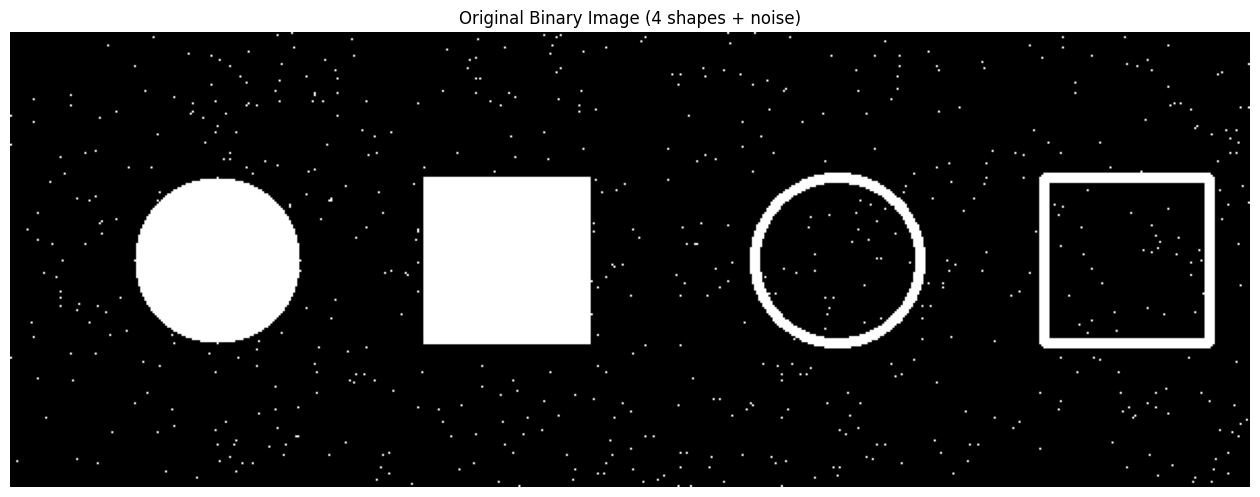

In [12]:
# Create a blank black image
image = np.zeros((220, 600), dtype=np.uint8)

# 1) Filled circle
cv2.circle(image, (100, 110), 40, 255, -1)

# 2) Filled square
cv2.rectangle(image, (200, 70), (280, 150), 255, -1)

# 3) Hollow circle
cv2.circle(image, (400, 110), 40, 255, 4)

# 4) Hollow square
cv2.rectangle(image, (500, 70), (580, 150), 255, 4)

# Add random white noise
np.random.seed(0)
noise_points = np.random.randint(0, [220, 600], size=(700, 2))
for y, x in noise_points:
    image[y, x] = 255

# Show the image
plt.figure(figsize=(16,6))
plt.imshow(image, cmap='gray')
plt.title("Original Binary Image (4 shapes + noise)")
plt.axis("off")
plt.show()

In [13]:
# 5x5 square kernel
square_kernel = np.ones((5, 5), np.uint8)

print("Square Kernel:")
print(square_kernel)

Square Kernel:
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


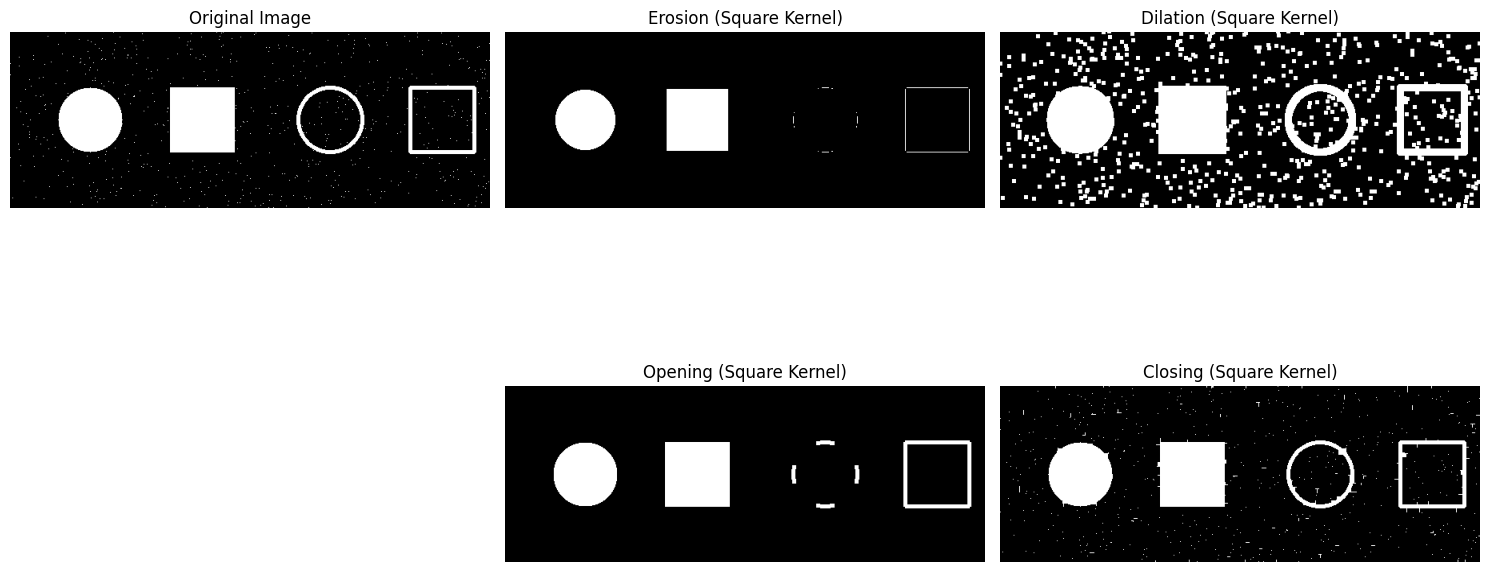

In [14]:
# Apply morphological operations using square kernel
eroded_square = cv2.erode(image, square_kernel, iterations=1)
dilated_square = cv2.dilate(image, square_kernel, iterations=1)
opened_square = cv2.morphologyEx(image, cv2.MORPH_OPEN, square_kernel)
closed_square = cv2.morphologyEx(image, cv2.MORPH_CLOSE, square_kernel)

# Display results
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(eroded_square, cmap='gray')
plt.title("Erosion (Square Kernel)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(dilated_square, cmap='gray')
plt.title("Dilation (Square Kernel)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(opened_square, cmap='gray')
plt.title("Opening (Square Kernel)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(closed_square, cmap='gray')
plt.title("Closing (Square Kernel)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
def circular_kernel(radius):
    size = 2 * radius + 1
    kernel = np.zeros((size, size), dtype=np.uint8)
    center = radius

    for i in range(size):
        for j in range(size):
            if (i - center) ** 2 + (j - center) ** 2 <= radius ** 2:
                kernel[i, j] = 1

    return kernel

In [16]:
circle_kernel = circular_kernel(2)

print("Circular Kernel:")
print(circle_kernel)

Circular Kernel:
[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


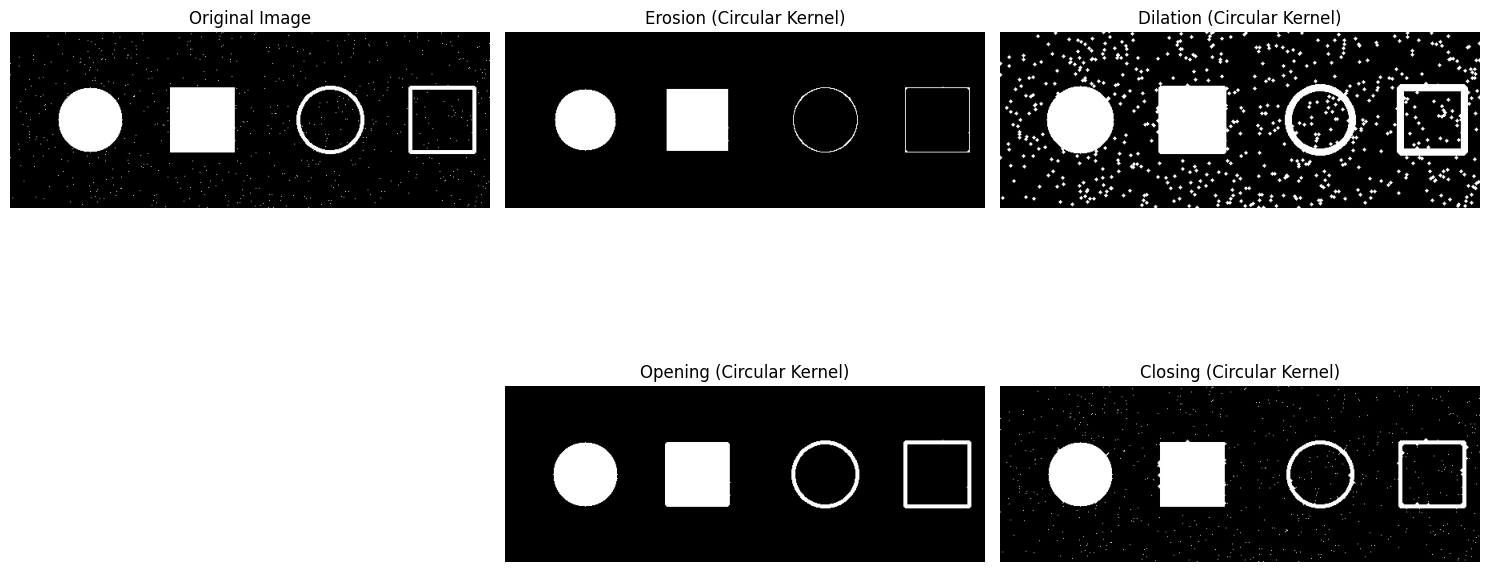

In [17]:
# Apply morphological operations using circular kernel
eroded_circle = cv2.erode(image, circle_kernel, iterations=1)
dilated_circle = cv2.dilate(image, circle_kernel, iterations=1)
opened_circle = cv2.morphologyEx(image, cv2.MORPH_OPEN, circle_kernel)
closed_circle = cv2.morphologyEx(image, cv2.MORPH_CLOSE, circle_kernel)

# Display results
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(eroded_circle, cmap='gray')
plt.title("Erosion (Circular Kernel)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(dilated_circle, cmap='gray')
plt.title("Dilation (Circular Kernel)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(opened_circle, cmap='gray')
plt.title("Opening (Circular Kernel)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(closed_circle, cmap='gray')
plt.title("Closing (Circular Kernel)")
plt.axis("off")

plt.tight_layout()
plt.show()

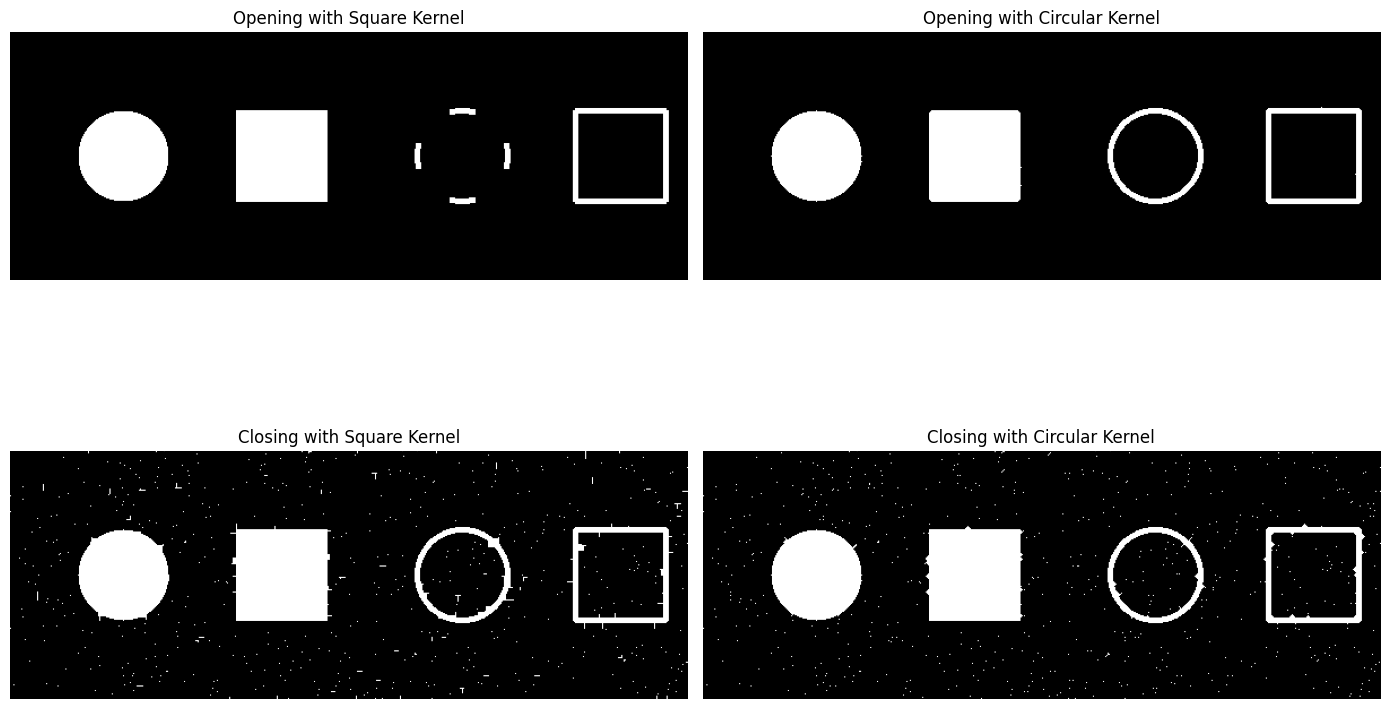

In [18]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(opened_square, cmap='gray')
plt.title("Opening with Square Kernel")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(opened_circle, cmap='gray')
plt.title("Opening with Circular Kernel")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(closed_square, cmap='gray')
plt.title("Closing with Square Kernel")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(closed_circle, cmap='gray')
plt.title("Closing with Circular Kernel")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
print("""
Comparison:

The square kernel affects the objects more sharply because it follows straight horizontal and vertical directions.
This can make the shapes look more blocky after erosion, dilation, opening, and closing.

The circular kernel preserves curved and rounded shapes better because it is symmetric in all directions.
The results look smoother and more natural, especially for circular objects.

So, the square kernel is simple and strong, but it may distort round objects.
The circular kernel is better when we want to preserve natural curved shapes.
""")


Comparison:

The square kernel affects the objects more sharply because it follows straight horizontal and vertical directions.
This can make the shapes look more blocky after erosion, dilation, opening, and closing.

The circular kernel preserves curved and rounded shapes better because it is symmetric in all directions.
The results look smoother and more natural, especially for circular objects.

So, the square kernel is simple and strong, but it may distort round objects.
The circular kernel is better when we want to preserve natural curved shapes.



In [20]:
plt.imsave("lab6_original.png", image, cmap='gray')
plt.imsave("lab6_eroded_square.png", eroded_square, cmap='gray')
plt.imsave("lab6_dilated_square.png", dilated_square, cmap='gray')
plt.imsave("lab6_opened_square.png", opened_square, cmap='gray')
plt.imsave("lab6_closed_square.png", closed_square, cmap='gray')

plt.imsave("lab6_eroded_circle.png", eroded_circle, cmap='gray')
plt.imsave("lab6_dilated_circle.png", dilated_circle, cmap='gray')
plt.imsave("lab6_opened_circle.png", opened_circle, cmap='gray')
plt.imsave("lab6_closed_circle.png", closed_circle, cmap='gray')

print("All Lab 6 output images saved successfully.")

All Lab 6 output images saved successfully.
